# Day 5: Functional and Noisy Signal Population
### Module: Data Analytics Foundations | Synthetic Data Generation & Signal Modeling

---

## Overview & Conceptual Foundations

In physical, financial, and industrial data analytics, real-world data is almost never perfectly pristine or purely random. Instead, it is composed of two fundamental forces:

$$\underbrace{y(t)}_{\text{Observed Data}} = \underbrace{f(t)}_{\text{Deterministic Signal / Ground Truth}} + \underbrace{\epsilon(t)}_{\text{Stochastic Noise / Measurement Error}}$$

1. **The Deterministic Ground Truth $f(t)$:** The underlying physical law, mathematical trend, economic relationship, or periodic harmonic oscillation (e.g. Newton's laws, seasonal sales cycles, heartbeat pulses).
2. **The Stochastic Error Term $\epsilon(t)$:** Uncontrollable measurement disturbances, thermal sensor noise, environmental turbulence, or random market volatility, typically modeled as White Gaussian Noise (WGN): $\epsilon \sim \mathcal{N}(0, \sigma^2)$.

### Signal-to-Noise Ratio (SNR)
The relative purity of a signal is quantified by the **Signal-to-Noise Ratio (SNR)**:

$$\text{SNR} = \frac{P_{\text{signal}}}{P_{\text{noise}}} = \frac{\text{Var}(f(t))}{\text{Var}(\epsilon(t))}$$

In engineering and data analytics, SNR is commonly expressed on the logarithmic decibel (dB) scale:

$$\text{SNR}_{\text{dB}} = 10 \cdot \log_{10}(\text{SNR})$$

- **High SNR ($> 20\text{ dB}$):** Clean, easily recognizable signal; noise is negligible.
- **Moderate SNR ($10 - 20\text{ dB}$):** Realistic industrial/sensor environment.
- **Low SNR ($< 5\text{ dB}$):** Severe noise; signal is visually buried and requires mathematical filtering or deep learning to extract.

In [10]:
# ==============================================================================
# STEP 1: SETUP IMPORTS AND RANDOM GENERATOR API
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy import stats

# Configure global visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Instantiate modern NumPy Generator instance for reproducible stochastic sampling
rng = np.random.default_rng(seed=42)

print("Environment initialized successfully!")
print(f"NumPy Version : {np.__version__}")
print(f"Pandas Version: {pd.__version__}")


Environment initialized successfully!
NumPy Version : 2.4.6
Pandas Version: 2.2.3


## 1. Periodic & Harmonic Signals with Additive Gaussian Noise

Periodic signals represent repeating oscillations found in electrical grids (AC voltage), vibrations, audio waveforms, and circadian biological rhythms:

$$f(t) = A \cdot \sin(2\pi f_0 t + \phi)$$

- **Amplitude ($A$):** Peak deviation of the wave from its center.
- **Frequency ($f_0$):** Number of complete oscillation cycles per second (Hz).
- **Phase ($\phi$):** Initial offset of the wave at $t = 0$.

When measurement devices record these signals, they superimpose **White Gaussian Noise (WGN)**:

$$y(t) = A \cdot \sin(2\pi f_0 t) + \epsilon(t) \quad \text{where } \epsilon(t) \sim \mathcal{N}(0, \sigma^2)$$

Signal Power Var(f)     : 2.0000
Low-Noise SNR           : 11.33 dB (Clean, easily recognizable)
High-Noise SNR          : 1.28 dB (Heavily degraded waveform)


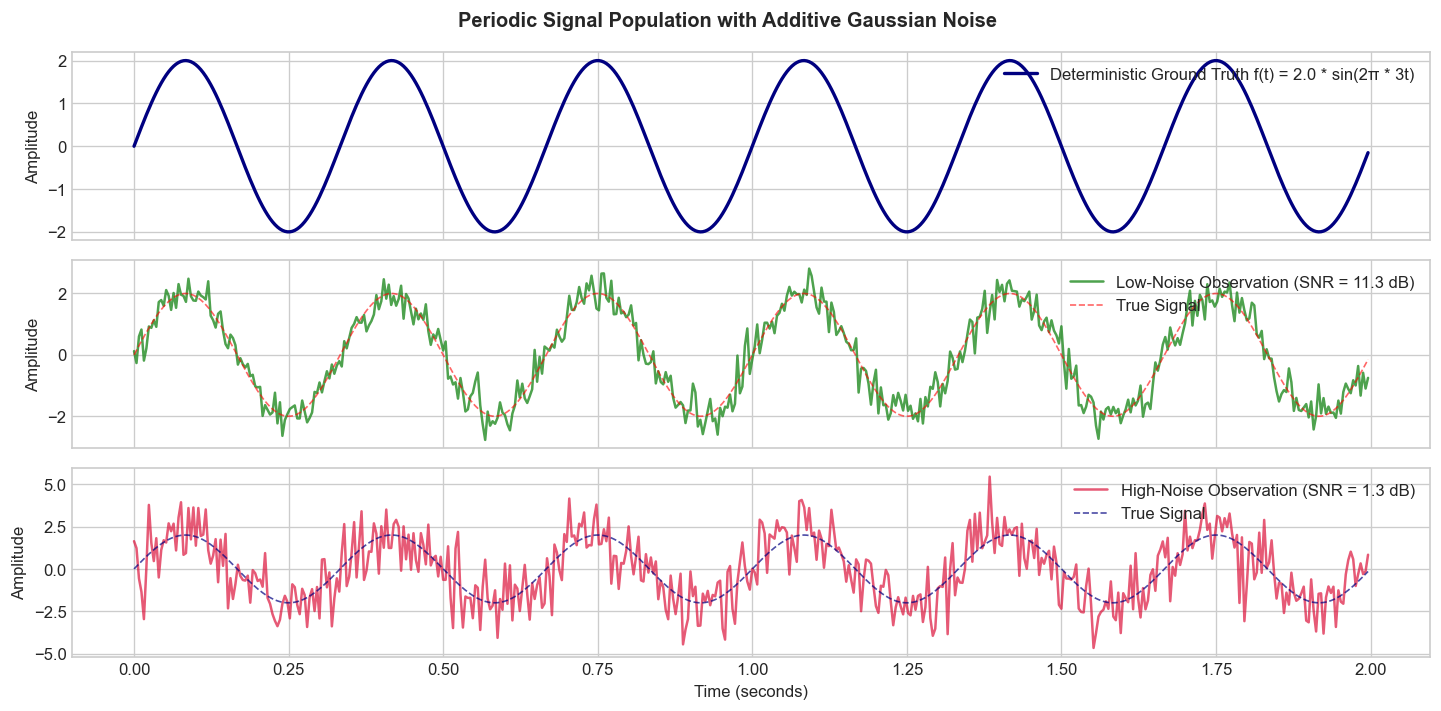

In [11]:
# ==============================================================================
# STEP 2: SYNTHESIZING CLEAN & NOISY PERIODIC SINE WAVES
# ==============================================================================

# 1. Define continuous time domain: 2 seconds of audio/sensor data sampled at 250 Hz (500 points)
duration = 2.0  # seconds
sampling_rate = 250  # samples per second (Hz)
N_samples = int(duration * sampling_rate)
t = np.linspace(0.0, duration, num=N_samples, endpoint=False)

# 2. Ground-Truth Periodic Function: A = 2.0, frequency f = 3.0 Hz
amplitude = 2.0
frequency = 3.0
clean_signal = amplitude * np.sin(2 * np.pi * frequency * t)

# 3. Additive Gaussian Noise at two different intensity levels
noise_low = rng.normal(loc=0.0, scale=0.4, size=N_samples)
noise_high = rng.normal(loc=0.0, scale=1.2, size=N_samples)

noisy_signal_low = clean_signal + noise_low
noisy_signal_high = clean_signal + noise_high

# 4. Calculate Empirical Signal-to-Noise Ratio (SNR) in Decibels (dB)
power_signal = np.var(clean_signal)
snr_low_db = 10 * np.log10(power_signal / np.var(noise_low))
snr_high_db = 10 * np.log10(power_signal / np.var(noise_high))

print(f"Signal Power Var(f)     : {power_signal:.4f}")
print(f"Low-Noise SNR           : {snr_low_db:.2f} dB (Clean, easily recognizable)")
print(f"High-Noise SNR          : {snr_high_db:.2f} dB (Heavily degraded waveform)")

# 5. Plot Waveform Comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

axes[0].plot(t, clean_signal, color='navy', linewidth=2, label='Deterministic Ground Truth f(t) = 2.0 * sin(2π * 3t)')
axes[0].set_ylabel('Amplitude')
axes[0].legend(loc='upper right')

axes[1].plot(t, noisy_signal_low, color='forestgreen', alpha=0.8, label=f'Low-Noise Observation (SNR = {snr_low_db:.1f} dB)')
axes[1].plot(t, clean_signal, color='red', linestyle='--', linewidth=1, alpha=0.6, label='True Signal')
axes[1].set_ylabel('Amplitude')
axes[1].legend(loc='upper right')

axes[2].plot(t, noisy_signal_high, color='crimson', alpha=0.7, label=f'High-Noise Observation (SNR = {snr_high_db:.1f} dB)')
axes[2].plot(t, clean_signal, color='navy', linestyle='--', linewidth=1, alpha=0.7, label='True Signal')
axes[2].set_ylabel('Amplitude')
axes[2].set_xlabel('Time (seconds)')
axes[2].legend(loc='upper right')

plt.suptitle('Periodic Signal Population with Additive Gaussian Noise', fontweight='bold')
plt.tight_layout()
plt.show()


## 2. Polynomial & Non-Linear Curves for Regression Benchmarking

When testing regression algorithms (Linear Regression, Ridge, Lasso, Polynomial Features, Random Forest), data analysts generate **synthetic benchmark curves with controllable irreducible error $\sigma^2$**:

1. **Cubic Polynomial:** $f(x) = 0.5 x^3 - 2 x^2 - x + 10$
2. **Exponential Decay (Chemical Kinetics / Customer Retention):** $f(x) = 50 \cdot e^{-0.6 x}$

By controlling the exact ground truth function $f(x)$ and noise standard deviation $\sigma$, we can empirically evaluate:
- **Underfitting:** High bias (model too simple to capture $f(x)$).
- **Overfitting:** High variance (model memorizes stochastic noise $\epsilon$ rather than $f(x)$).

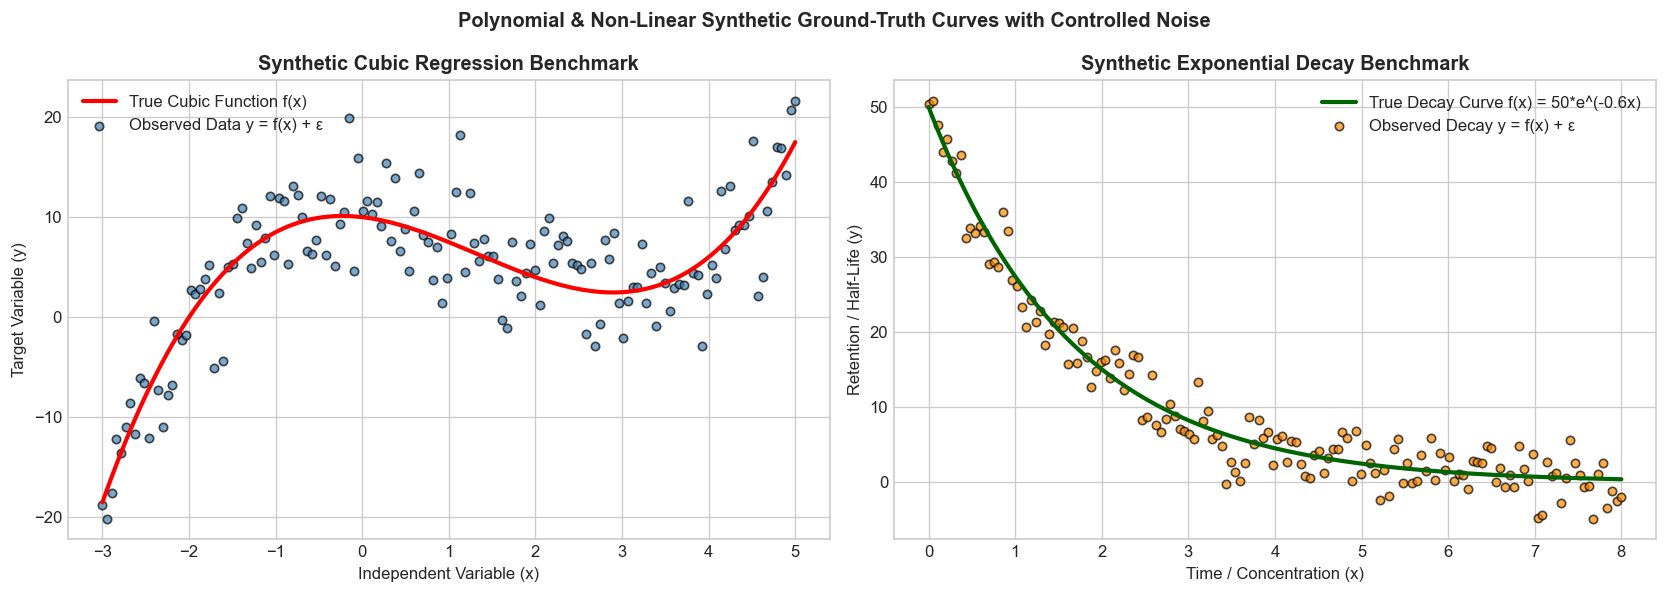

In [12]:
# ==============================================================================
# STEP 3: POLYNOMIAL & EXPONENTIAL GROUND TRUTHS FOR REGRESSION TESTING
# ==============================================================================

# 1. Polynomial Domain x in [-3, 5]
x_poly = np.linspace(-3.0, 5.0, num=150)

# Deterministic Ground-Truth Cubic Polynomial
y_poly_true = 0.5 * x_poly**3 - 2.0 * x_poly**2 - x_poly + 10.0

# Additive Gaussian Measurement Noise
noise_poly = rng.normal(loc=0.0, scale=4.0, size=len(x_poly))
y_poly_noisy = y_poly_true + noise_poly

# 2. Exponential Decay Domain x in [0, 8]
x_exp = np.linspace(0.0, 8.0, num=150)

# Ground Truth: Customer retention / Radioactive decay A * exp(-lambda * x)
y_exp_true = 50.0 * np.exp(-0.6 * x_exp)
noise_exp = rng.normal(loc=0.0, scale=2.5, size=len(x_exp))
y_exp_noisy = y_exp_true + noise_exp

# 3. Plotting Regression Target Benchmarks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polynomial Subplot
axes[0].plot(x_poly, y_poly_true, color='red', linewidth=2.5, label='True Cubic Function f(x)', zorder=3)
axes[0].scatter(x_poly, y_poly_noisy, color='steelblue', s=25, alpha=0.7, edgecolors='black', label='Observed Data y = f(x) + ε')
axes[0].set_title('Synthetic Cubic Regression Benchmark', fontweight='bold')
axes[0].set_xlabel('Independent Variable (x)')
axes[0].set_ylabel('Target Variable (y)')
axes[0].legend()

# Exponential Decay Subplot
axes[1].plot(x_exp, y_exp_true, color='darkgreen', linewidth=2.5, label='True Decay Curve f(x) = 50*e^(-0.6x)', zorder=3)
axes[1].scatter(x_exp, y_exp_noisy, color='darkorange', s=25, alpha=0.7, edgecolors='black', label='Observed Decay y = f(x) + ε')
axes[1].set_title('Synthetic Exponential Decay Benchmark', fontweight='bold')
axes[1].set_xlabel('Time / Concentration (x)')
axes[1].set_ylabel('Retention / Half-Life (y)')
axes[1].legend()

plt.suptitle('Polynomial & Non-Linear Synthetic Ground-Truth Curves with Controlled Noise', fontweight='bold')
plt.tight_layout()
plt.show()


## 2.5 Polynomial Function with Sparse Outliers (Impulse Noise & Robust Estimation)

### The Real-World Problem: Contaminated Data & Sensor Glitches
In real-world data pipelines (industrial IoT sensors, automated trading systems, laboratory assays), data corruption rarely consists of gentle Gaussian noise alone. Instead, data frequently suffers from **Sparse Outliers / Impulse Noise** (also known as Salt-and-Pepper noise or Heavy-Tailed contamination):

$$\underbrace{y_i}_{\text{Observed Data}} = \underbrace{P(x_i)}_{\text{Polynomial Ground Truth}} + \underbrace{\epsilon_i}_{\text{Dense Gaussian Noise } \mathcal{N}(0, \sigma^2)} + \underbrace{\eta_i}_{\text{Sparse Impulse Outliers}}$$

Where the outlier process $\eta_i$ follows a Bernoulli-Uniform mixture:
$$\eta_i = B_i \cdot U_i \quad \text{where } B_i \sim \text{Bernoulli}(p), \quad U_i \sim \text{Uniform}(\pm M_1, \pm M_2)$$
- $p \ll 1$ (e.g. $p = 0.06$, only $6\%$ of points are corrupted).
- $M_1 \gg \sigma$ (outlier magnitude dwarfs standard noise, e.g. spikes of $\pm 50$).

### Why Standard Polynomial Regression (OLS / MSE) Breaks:
Ordinary Least Squares (OLS) minimizes the sum of squared residuals:
$$\min_{\beta} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
Because residual errors are **squared**, an outlier with error $e = 50$ generates a penalty of $50^2 = 2500$! This immense leverage tilts, shifts, and twists the fitted polynomial, completely degrading predictions for the clean $94\%$ of the dataset.

### How Robust Regression (RANSAC & Huber) Solves It:
1. **RANSAC (Random Sample Consensus):**
   - Repeatedly fits the polynomial to minimal random subsets of data points (e.g. 3 points for a quadratic).
   - Counts how many remaining points agree within a consensus threshold $\tau$ (the "inlier consensus").
   - Retrains the final polynomial strictly on the identified inliers, completely discarding the sparse outliers!
2. **Huber Regressor:**
   - Employs a hybrid loss function: quadratic $r^2$ for small residuals ($|r| \le \delta$), and linear $|r|$ for large residuals ($|r| > \delta$), neutralizing outlier leverage.

      POLYNOMIAL WITH SPARSE OUTLIERS: OLS VS. RANSAC PERFORMANCE       
Total Observations               : 100 points
Injected Sparse Outliers         : 6 points (6% of data)
Standard OLS Inlier RMSE         : 3.4269 (Severely distorted by outlier leverage)
Robust RANSAC Inlier RMSE        : 0.9254 (Accurately tracks ground truth)
Error Reduction via Robust Fit   : 73.0%


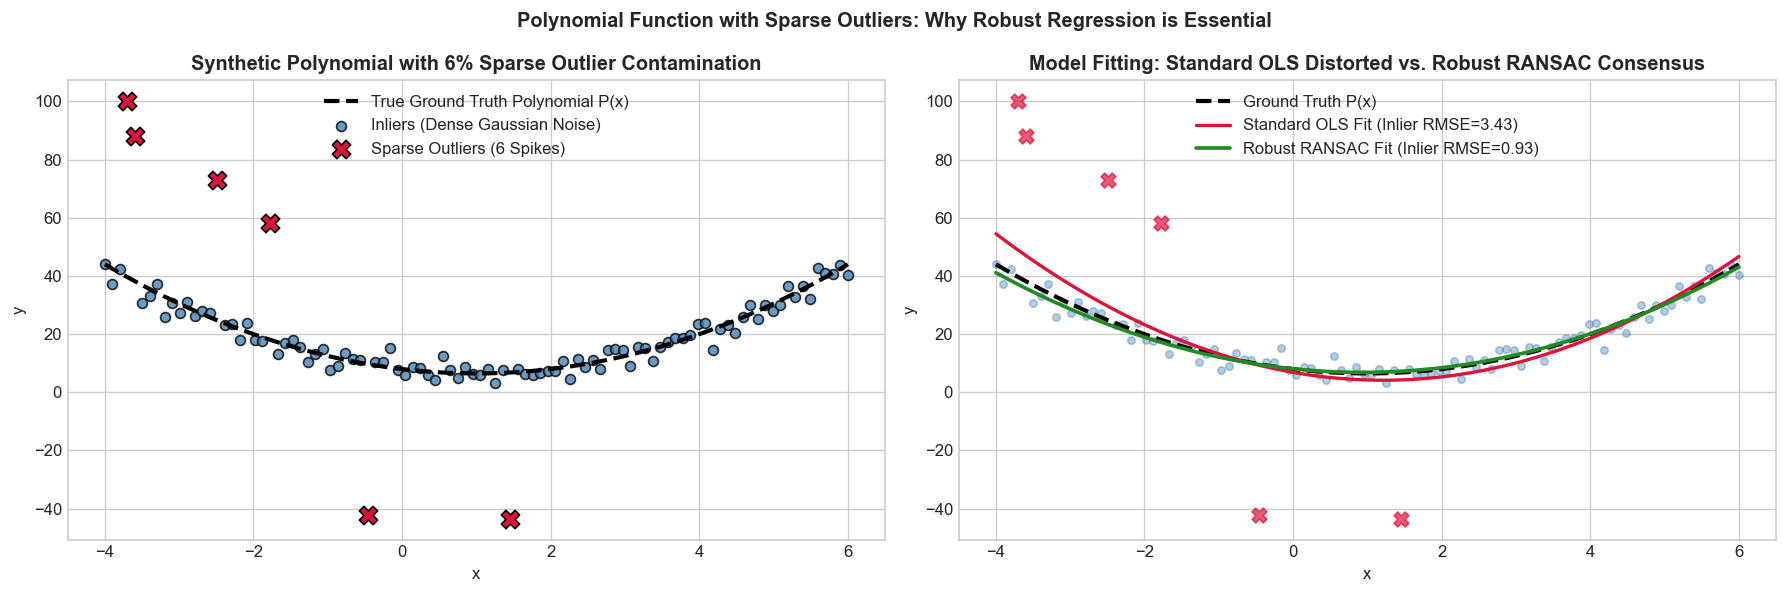

In [13]:
# ==============================================================================
# STEP 3.5: POLYNOMIAL FUNCTION WITH SPARSE OUTLIERS & ROBUST REGRESSION
# ==============================================================================
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Define Ground-Truth Quadratic Polynomial: P(x) = 1.5*x^2 - 3.0*x + 8.0
N = 100
x = np.linspace(-4.0, 6.0, N)
y_true = 1.5 * x**2 - 3.0 * x + 8.0

# 2. Add Dense Background Gaussian Measurement Noise (sigma = 2.5)
gaussian_noise = rng.normal(loc=0.0, scale=2.5, size=N)
y_noisy = y_true + gaussian_noise

# 3. Inject Sparse Extreme Outliers (Impulses) into 6% of the points
outlier_fraction = 0.06
n_outliers = int(outlier_fraction * N)  # 6 outlier points out of 100
outlier_indices = rng.choice(N, size=n_outliers, replace=False)

y_corrupted = y_noisy.copy()
# Inject large positive and negative spikes (+35 to +60 or -35 to -60)
spike_signs = rng.choice([-1, 1], size=n_outliers)
spike_magnitudes = rng.uniform(35.0, 60.0, size=n_outliers)
y_corrupted[outlier_indices] += spike_signs * spike_magnitudes

# 4. Fit Model A: Standard Polynomial Regression (OLS / Mean Squared Error)
# OLS squares residuals, giving massive leverage to the 6 outliers
ols_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
ols_poly.fit(x[:, np.newaxis], y_corrupted)
y_pred_ols = ols_poly.predict(x[:, np.newaxis])

# 5. Fit Model B: Robust RANSAC Polynomial Regression
# RANSAC identifies consensus inliers and completely discards sparse outliers
ransac_poly = make_pipeline(PolynomialFeatures(degree=2), RANSACRegressor(random_state=42))
ransac_poly.fit(x[:, np.newaxis], y_corrupted)
y_pred_ransac = ransac_poly.predict(x[:, np.newaxis])

# 6. Evaluate Reconstruction Accuracy on Inlier (Clean) Data
inlier_mask = np.ones(N, dtype=bool)
inlier_mask[outlier_indices] = False

rmse_ols_inliers = np.sqrt(np.mean((y_pred_ols[inlier_mask] - y_true[inlier_mask])**2))
rmse_ransac_inliers = np.sqrt(np.mean((y_pred_ransac[inlier_mask] - y_true[inlier_mask])**2))

print("=" * 75)
print("      POLYNOMIAL WITH SPARSE OUTLIERS: OLS VS. RANSAC PERFORMANCE       ")
print("=" * 75)
print(f"Total Observations               : {N} points")
print(f"Injected Sparse Outliers         : {n_outliers} points ({outlier_fraction*100:.0f}% of data)")
print(f"Standard OLS Inlier RMSE         : {rmse_ols_inliers:.4f} (Severely distorted by outlier leverage)")
print(f"Robust RANSAC Inlier RMSE        : {rmse_ransac_inliers:.4f} (Accurately tracks ground truth)")
print(f"Error Reduction via Robust Fit   : {(1 - rmse_ransac_inliers/rmse_ols_inliers)*100:.1f}%")

# 7. Plotting OLS vs. Robust RANSAC Polynomial Fitting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Ground Truth vs. Data with Sparse Outliers Highlighted
axes[0].plot(x, y_true, color='black', linestyle='--', linewidth=2.5, label='True Ground Truth Polynomial P(x)')
axes[0].scatter(x[inlier_mask], y_corrupted[inlier_mask], color='steelblue', s=35, alpha=0.8, edgecolors='black', label='Inliers (Dense Gaussian Noise)')
axes[0].scatter(x[outlier_indices], y_corrupted[outlier_indices], color='crimson', marker='X', s=120, edgecolors='black', label=f'Sparse Outliers ({n_outliers} Spikes)', zorder=5)
axes[0].set_title('Synthetic Polynomial with 6% Sparse Outlier Contamination', fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(loc='upper center')

# Subplot 2: Model Comparison - OLS vs. RANSAC
axes[1].plot(x, y_true, color='black', linestyle='--', linewidth=2.5, label='Ground Truth P(x)')
axes[1].plot(x, y_pred_ols, color='crimson', linewidth=2.0, label=f'Standard OLS Fit (Inlier RMSE={rmse_ols_inliers:.2f})')
axes[1].plot(x, y_pred_ransac, color='forestgreen', linewidth=2.2, label=f'Robust RANSAC Fit (Inlier RMSE={rmse_ransac_inliers:.2f})')
axes[1].scatter(x[inlier_mask], y_corrupted[inlier_mask], color='steelblue', s=20, alpha=0.4)
axes[1].scatter(x[outlier_indices], y_corrupted[outlier_indices], color='crimson', marker='X', s=80, alpha=0.7)
axes[1].set_title('Model Fitting: Standard OLS Distorted vs. Robust RANSAC Consensus', fontweight='bold')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].legend(loc='upper center')

plt.suptitle('Polynomial Function with Sparse Outliers: Why Robust Regression is Essential', fontweight='bold')
plt.tight_layout()
plt.show()


## 2.7 Multi-Component Composite Signal with Heteroscedastic Noise

### Motivation: Real-World Signals Are Never Single-Frequency, Never Uniform-Noise

Physical systems routinely combine multiple **periodic, trend, and stochastic** components into a single measured time-series. Simultaneously, the **noise amplitude itself changes over time** — a property called **Heteroscedasticity** (Greek: *hetero* = different, *skedasis* = dispersion).

**Composite Signal Model:**

$$s(t) = \underbrace{A_1 \sin(2\pi f_1 t + \phi_1)}_{\text{Fundamental Harmonic}} + \underbrace{A_2 \sin(2\pi f_2 t + \phi_2)}_{\text{2nd Harmonic Overtone}} + \underbrace{A_3 \cos(2\pi f_3 t + \phi_3)}_{\text{3rd Harmonic Overtone}} + \underbrace{\alpha t^2}_{\text{Quadratic Trend}} + \underbrace{\epsilon(t)}_{\text{Heteroscedastic Noise}}$$

**Heteroscedastic Noise:**

$$\epsilon(t) = \mathcal{N}\!\left(0,\ \sigma^2(t)\right) \quad \text{where} \quad \sigma(t) = \sigma_0 \cdot \left(1 + \beta\, |s_{\text{clean}}(t)|\right)$$

- $\sigma_0$ = base noise floor
- $\beta$ = heteroscedasticity coefficient — noise amplitude **scales with signal magnitude**
- Variance is **non-constant**: OLS / WLS assumptions of homoscedasticity are violated!

### Analytical Decomposition:
| Component | Frequency | Amplitude | Phase | Role |
|:---|:---:|:---:|:---:|:---|
| Fundamental $f_1$ | 1.0 Hz | 5.0 | 0.0 | Primary oscillation |
| 2nd Harmonic $f_2$ | 2.5 Hz | 2.5 | π/4 | Overtone distortion |
| 3rd Harmonic $f_3$ | 0.4 Hz | 3.5 | π/6 | Low-frequency modulation |
| Quadratic Trend | — | α=0.08 | — | Slow drift / nonstationary mean |
| Heterosc. Noise | — | σ₀=0.8, β=0.15 | — | Amplitude-dependent variance |

### Why This Matters for Data Analytics:
1. **Spectral Analysis (FFT)** can unmix the harmonic components from the composite.
2. **Breusch-Pagan / White's Test** can formally detect heteroscedasticity.
3. **Weighted Least Squares (WLS)** or **ARCH / GARCH** models correctly handle non-constant variance.
4. **Detrending** (removing $\alpha t^2$) is a prerequisite for reliable spectral estimation.


    MULTI-COMPONENT COMPOSITE SIGNAL – HETEROSCEDASTIC NOISE SUMMARY    
Sampling Rate          : 200 Hz   |  Duration: 5.0 s  |  Samples: 1000
Harmonic Components    : f1=1.0 Hz (A=5.0), f2=2.5 Hz (A=2.5), f3=0.4 Hz (A=3.5)
Quadratic Trend        : α=0.08  (drift at t=5s → 2.00 units)
Base Noise Floor σ₀    : 0.8
Heteroscedast. Coeff β : 0.15  → σ ranges [0.80, 1.86]
Observed Signal SNR    : 11.03 dB
FFT Peak Frequencies   : ['1.00 Hz', '0.40 Hz', '2.40 Hz', '2.60 Hz']


C:\Users\conne\AppData\Local\Temp\ipykernel_15592\3212617153.py:119: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\conne\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


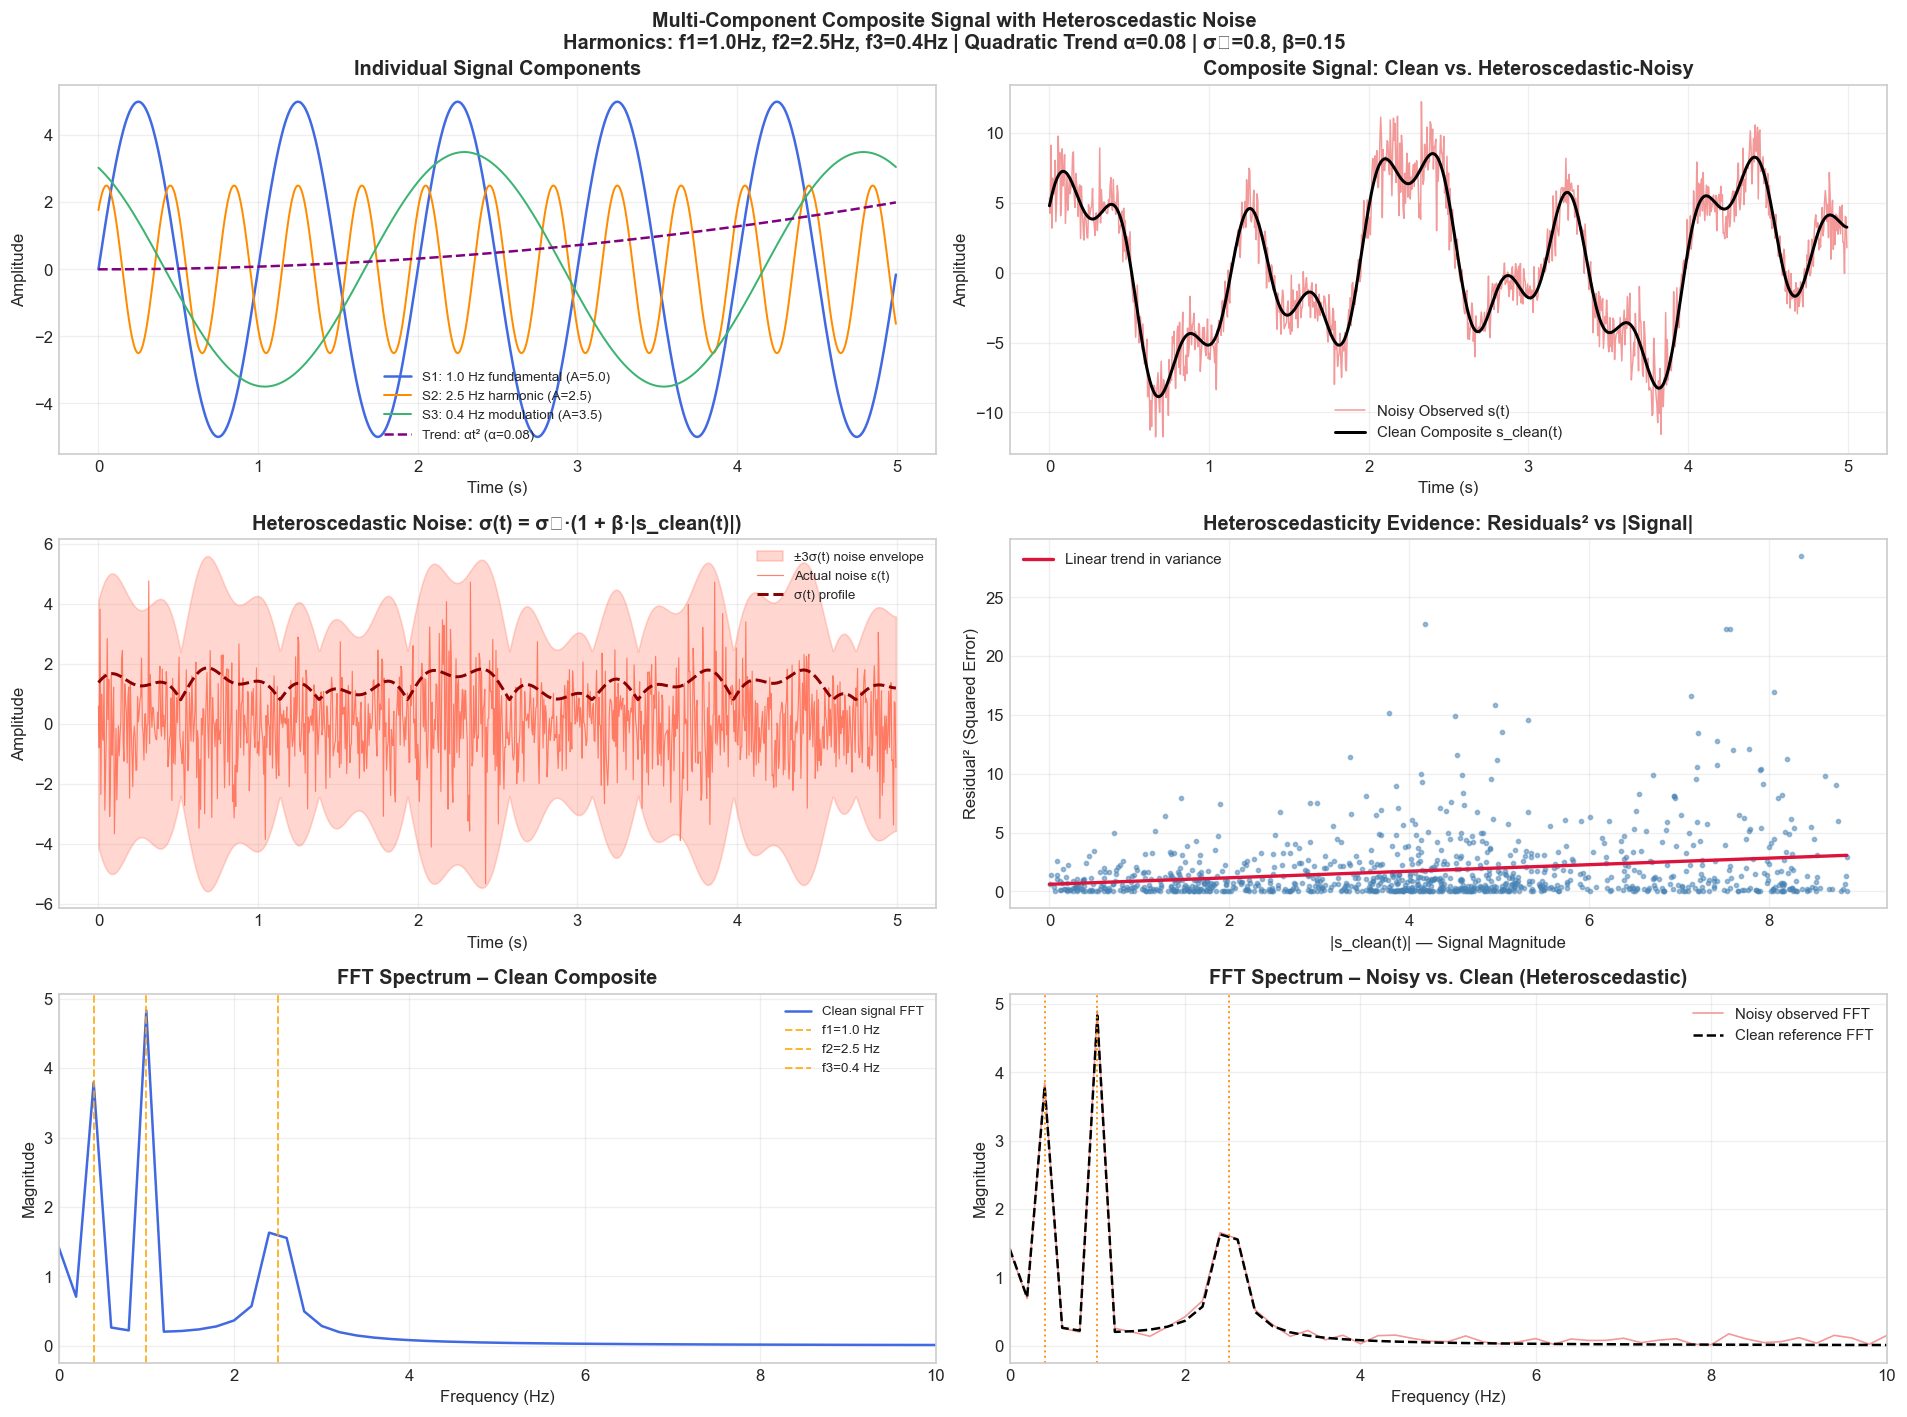

In [14]:
# ==============================================================================
# SECTION 2.7: MULTI-COMPONENT COMPOSITE SIGNAL WITH HETEROSCEDASTIC NOISE
# ==============================================================================

# 1. Time axis (5 seconds, 1000 samples → 200 Hz sampling rate)
T_TOTAL   = 5.0
FS        = 200           # sampling frequency (Hz)
t = np.linspace(0, T_TOTAL, int(T_TOTAL * FS), endpoint=False)

# 2. Define Multi-Component Clean Signal Parameters
# Component 1: Fundamental harmonic  f1 = 1.0 Hz, A1 = 5.0
A1, f1, phi1 = 5.0, 1.0, 0.0
# Component 2: 2nd harmonic overtone f2 = 2.5 Hz, A2 = 2.5
A2, f2, phi2 = 2.5, 2.5, np.pi / 4
# Component 3: Low-freq modulation   f3 = 0.4 Hz, A3 = 3.5
A3, f3, phi3 = 3.5, 0.4, np.pi / 6
# Quadratic trend drift
alpha = 0.08

s1     = A1 * np.sin(2 * np.pi * f1 * t + phi1)
s2     = A2 * np.sin(2 * np.pi * f2 * t + phi2)
s3     = A3 * np.cos(2 * np.pi * f3 * t + phi3)
trend  = alpha * t**2
s_clean = s1 + s2 + s3 + trend          # pure composite (no noise)

# 3. Generate Heteroscedastic Noise
# σ(t) = σ₀ * (1 + β * |s_clean(t)|)  ← noise variance scales with signal!
sigma_0 = 0.8     # base noise floor
beta    = 0.15    # heteroscedasticity coefficient
sigma_t = sigma_0 * (1.0 + beta * np.abs(s_clean))
rng2    = np.random.default_rng(seed=77)
noise   = rng2.normal(loc=0.0, scale=sigma_t)
s_obs   = s_clean + noise              # noisy observed signal

# 4. FFT – recover frequency components from the noisy composite
N_fft = len(t)
freqs = np.fft.rfftfreq(N_fft, d=1.0/FS)
fft_clean = np.abs(np.fft.rfft(s_clean)) * 2 / N_fft
fft_obs   = np.abs(np.fft.rfft(s_obs))   * 2 / N_fft

# 5. Print Summary Statistics
print('=' * 75)
print('    MULTI-COMPONENT COMPOSITE SIGNAL – HETEROSCEDASTIC NOISE SUMMARY    ')
print('=' * 75)
print(f'Sampling Rate          : {FS} Hz   |  Duration: {T_TOTAL} s  |  Samples: {N_fft}')
print(f'Harmonic Components    : f1={f1} Hz (A={A1}), f2={f2} Hz (A={A2}), f3={f3} Hz (A={A3})')
print(f'Quadratic Trend        : α={alpha}  (drift at t=5s → {alpha*T_TOTAL**2:.2f} units)')
print(f'Base Noise Floor σ₀    : {sigma_0}')
print(f'Heteroscedast. Coeff β : {beta}  → σ ranges [{sigma_t.min():.2f}, {sigma_t.max():.2f}]')
print(f'Observed Signal SNR    : {10*np.log10(np.var(s_clean)/np.var(noise)):.2f} dB')
peak_freqs = freqs[np.argsort(fft_clean)[-4:][::-1]]
print(f'FFT Peak Frequencies   : {[f"{pf:.2f} Hz" for pf in peak_freqs]}')

# 6. ── Plotting ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# ── Row 1: Time-domain ──────────────────────────────────────────────────
# Left: Component decomposition
axes[0, 0].plot(t, s1,     color='royalblue',  lw=1.5, label=f'S1: {f1} Hz fundamental (A={A1})')
axes[0, 0].plot(t, s2,     color='darkorange',  lw=1.2, label=f'S2: {f2} Hz harmonic (A={A2})')
axes[0, 0].plot(t, s3,     color='mediumseagreen', lw=1.2, label=f'S3: {f3} Hz modulation (A={A3})')
axes[0, 0].plot(t, trend,  color='purple',      lw=1.5, linestyle='--', label=f'Trend: αt² (α={alpha})')
axes[0, 0].set_title('Individual Signal Components', fontweight='bold')
axes[0, 0].set_xlabel('Time (s)'); axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].legend(fontsize=8); axes[0, 0].grid(alpha=0.3)

# Right: Clean composite vs noisy observed
axes[0, 1].plot(t, s_obs,   color='lightcoral', lw=0.9, alpha=0.8, label='Noisy Observed s(t)')
axes[0, 1].plot(t, s_clean, color='black',       lw=1.8, label='Clean Composite s_clean(t)')
axes[0, 1].set_title('Composite Signal: Clean vs. Heteroscedastic-Noisy', fontweight='bold')
axes[0, 1].set_xlabel('Time (s)'); axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].legend(fontsize=9); axes[0, 1].grid(alpha=0.3)

# ── Row 2: Noise analysis ────────────────────────────────────────────────
# Left: σ(t) — heteroscedastic variance profile over time
axes[1, 0].fill_between(t, -3*sigma_t, 3*sigma_t, alpha=0.25, color='tomato', label='±3σ(t) noise envelope')
axes[1, 0].plot(t, noise,   color='tomato', lw=0.7, alpha=0.8, label='Actual noise ε(t)')
axes[1, 0].plot(t, sigma_t, color='darkred', lw=1.8, linestyle='--', label='σ(t) profile')
axes[1, 0].set_title('Heteroscedastic Noise: σ(t) = σ₀·(1 + β·|s_clean(t)|)', fontweight='bold')
axes[1, 0].set_xlabel('Time (s)'); axes[1, 0].set_ylabel('Amplitude')
axes[1, 0].legend(fontsize=8); axes[1, 0].grid(alpha=0.3)

# Right: Residuals² vs |s_clean| — visually proves heteroscedasticity
residuals = s_obs - s_clean
axes[1, 1].scatter(np.abs(s_clean), residuals**2, color='steelblue', s=6, alpha=0.5)
from numpy.polynomial import polynomial as P
fit_c = P.polyfit(np.abs(s_clean), residuals**2, deg=1)
x_fit = np.linspace(0, np.abs(s_clean).max(), 200)
axes[1, 1].plot(x_fit, P.polyval(x_fit, fit_c), color='crimson', lw=2, label='Linear trend in variance')
axes[1, 1].set_title('Heteroscedasticity Evidence: Residuals² vs |Signal|', fontweight='bold')
axes[1, 1].set_xlabel('|s_clean(t)| — Signal Magnitude')
axes[1, 1].set_ylabel('Residual² (Squared Error)')
axes[1, 1].legend(fontsize=9); axes[1, 1].grid(alpha=0.3)

# ── Row 3: Frequency domain (FFT) ────────────────────────────────────────
# Left: FFT of clean signal — peaks at f1, f2, f3
axes[2, 0].plot(freqs, fft_clean, color='royalblue', lw=1.5, label='Clean signal FFT')
for fc, lbl in [(f1, 'f1'), (f2, 'f2'), (f3, 'f3')]:
    axes[2, 0].axvline(x=fc, color='orange', lw=1.2, linestyle='--', alpha=0.8, label=f'{lbl}={fc} Hz')
axes[2, 0].set_xlim(0, 10); axes[2, 0].set_title('FFT Spectrum – Clean Composite', fontweight='bold')
axes[2, 0].set_xlabel('Frequency (Hz)'); axes[2, 0].set_ylabel('Magnitude')
axes[2, 0].legend(fontsize=8); axes[2, 0].grid(alpha=0.3)

# Right: FFT of noisy signal — peaks still recoverable
axes[2, 1].plot(freqs, fft_obs, color='lightcoral', lw=1.0, alpha=0.8, label='Noisy observed FFT')
axes[2, 1].plot(freqs, fft_clean, color='black', lw=1.5, linestyle='--', label='Clean reference FFT')
for fc in [f1, f2, f3]:
    axes[2, 1].axvline(x=fc, color='darkorange', lw=1.2, linestyle=':', alpha=0.9)
axes[2, 1].set_xlim(0, 10); axes[2, 1].set_title('FFT Spectrum – Noisy vs. Clean (Heteroscedastic)', fontweight='bold')
axes[2, 1].set_xlabel('Frequency (Hz)'); axes[2, 1].set_ylabel('Magnitude')
axes[2, 1].legend(fontsize=9); axes[2, 1].grid(alpha=0.3)

plt.suptitle(
    'Multi-Component Composite Signal with Heteroscedastic Noise\n'
    f'Harmonics: f1={f1}Hz, f2={f2}Hz, f3={f3}Hz | Quadratic Trend α={alpha} | '
    f'σ₀={sigma_0}, β={beta}',
    fontweight='bold', fontsize=12
)
plt.tight_layout()
plt.show()


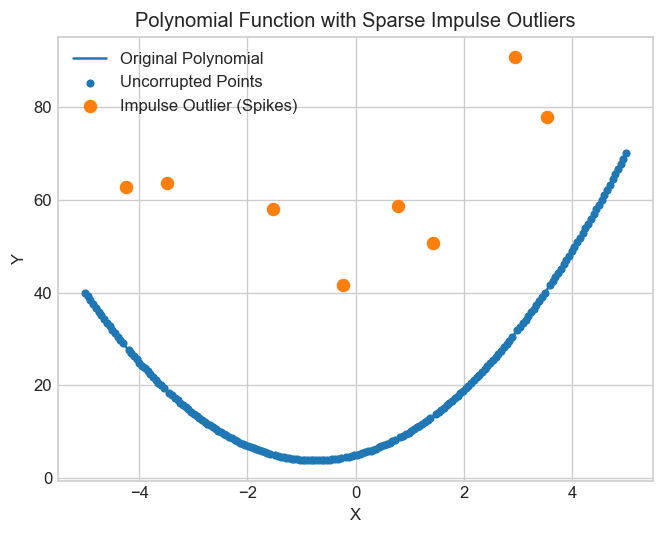

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible random numbers
np.random.seed(42)

# --------------------------------------------------
# 1. Create x values
# --------------------------------------------------
x_poly = np.linspace(-5, 5, 200)

# --------------------------------------------------
# 2. Create the original polynomial signal
#    y = 2x² + 3x + 5
# --------------------------------------------------
y_poly = 2 * x_poly**2 + 3 * x_poly + 5

# --------------------------------------------------
# 3. Create a corrupted copy
# --------------------------------------------------
y_poly_corrupted = y_poly.copy()

# --------------------------------------------------
# 4. Select a few random points as outliers
# --------------------------------------------------
num_outliers = 8

outlier_indices = np.random.choice(
    len(x_poly),
    size=num_outliers,
    replace=False
)

# --------------------------------------------------
# 5. Add large impulse/spike values
# --------------------------------------------------
outlier_values = np.random.uniform(30, 60, num_outliers)

y_poly_corrupted[outlier_indices] += outlier_values

# --------------------------------------------------
# 6. Create mask for normal/uncorrupted points
# --------------------------------------------------
normal_mask = np.ones_like(x_poly, dtype=bool)

# Outlier positions become False
normal_mask[outlier_indices] = False

# --------------------------------------------------
# 7. Plot original polynomial
# --------------------------------------------------
plt.plot(
    x_poly,
    y_poly,
    label="Original Polynomial"
)

# --------------------------------------------------
# 8. Plot normal observations
# --------------------------------------------------
plt.scatter(
    x_poly[normal_mask],
    y_poly_corrupted[normal_mask],
    label="Uncorrupted Points",
    s=15
)

# --------------------------------------------------
# 9. Plot outliers
# --------------------------------------------------
plt.scatter(
    x_poly[outlier_indices],
    y_poly_corrupted[outlier_indices],
    label="Impulse Outlier (Spikes)",
    s=50
)

# --------------------------------------------------
# 10. Labels and display
# --------------------------------------------------
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Function with Sparse Impulse Outliers")

plt.legend()
plt.grid(True)

plt.show()

## 3. Stochastic Time-Series Processes: Random Walks & Autoregression

Unlike memoryless measurements, sequential time-series data exhibits **temporal autocorrelation**, where current observations depend on previous states:

### A. Pure Random Walk (Brownian Motion / Efficient Market Hypothesis):
Used for modeling stock prices, currency exchange rates, and molecular diffusion:

$$P_t = P_{t-1} + \epsilon_t \implies P_t = P_0 + \sum_{i=1}^t \epsilon_i = P_0 + \text{cumsum}(\epsilon)$$

### B. Random Walk with Deterministic Drift:
Models secular economic growth or inflation combined with random market shocks:

$$P_t = P_{t-1} + \mu_{\text{drift}} + \epsilon_t$$

### C. Autoregressive Process AR(1) (Mean-Reverting):
Models stationary systems (e.g. ambient temperature, interest rates, commodity prices) that oscillate around a long-term equilibrium $\mu_0$:

$$X_t = c + \phi X_{t-1} + \epsilon_t \quad \text{where } |\phi| < 1$$

- If $\phi \rightarrow 1$: Approaches a non-stationary random walk.
- If $\phi < 1$: Stationary mean-reverting process with equilibrium mean $\frac{c}{1 - \phi}$.

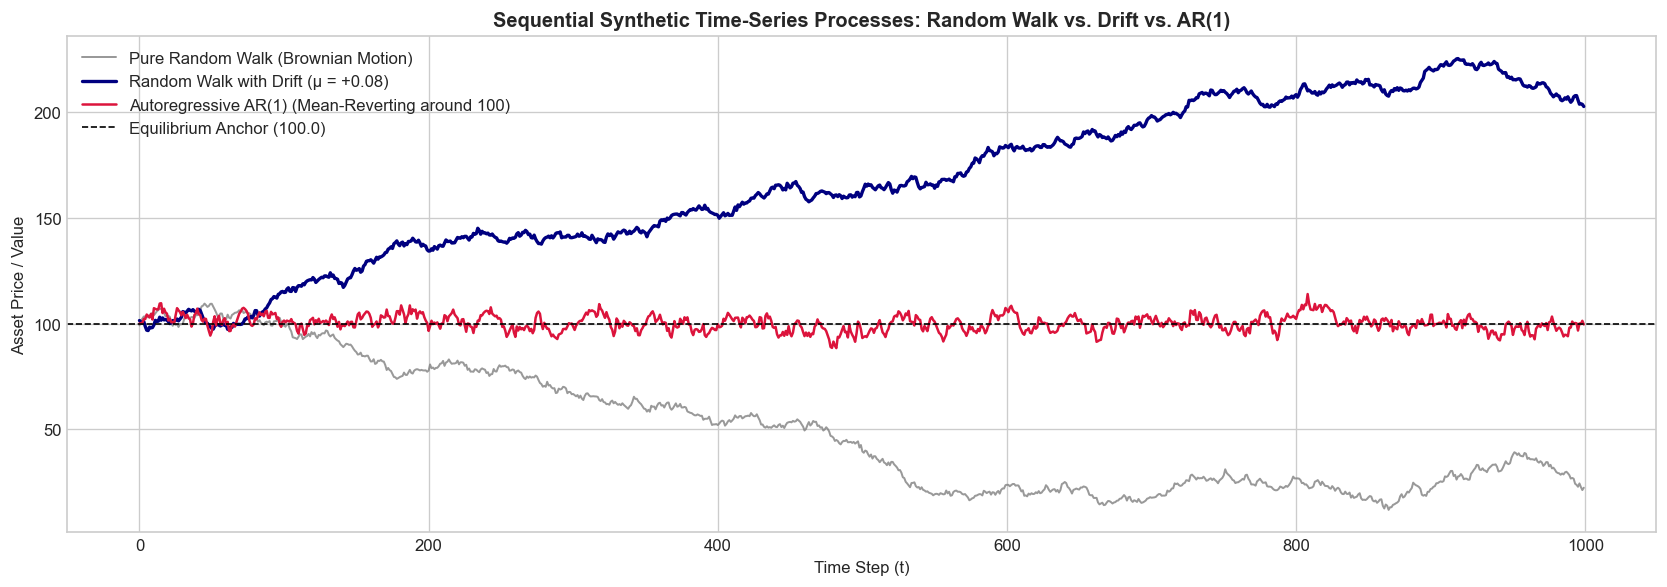

In [16]:
# ==============================================================================
# STEP 4: SIMULATING RANDOM WALKS & AUTOREGRESSIVE AR(1) TIME SERIES
# ==============================================================================
N_steps = 1_000
initial_price = 100.0

# 1. Pure Random Walk: Cumsum of i.i.d. normal steps
shocks = rng.normal(loc=0.0, scale=1.0, size=N_steps)
random_walk_pure = initial_price + np.cumsum(shocks)

# 2. Random Walk with Positive Economic Drift (+0.08 units/step)
drift = 0.08
drift_shocks = rng.normal(loc=drift, scale=1.0, size=N_steps)
random_walk_drift = initial_price + np.cumsum(drift_shocks)

# 3. Mean-Reverting Autoregressive AR(1) Process (phi = 0.85, target mean = 100)
phi = 0.85
c_const = 100.0 * (1.0 - phi)  # Equilibrium mean = c / (1 - phi) = 100.0
ar1_series = np.zeros(N_steps)
ar1_series[0] = initial_price

for t_idx in range(1, N_steps):
    ar1_series[t_idx] = c_const + phi * ar1_series[t_idx - 1] + rng.normal(loc=0.0, scale=2.0)

# 4. Plot Time-Series Processes
plt.figure(figsize=(14, 5))
plt.plot(random_walk_pure, label='Pure Random Walk (Brownian Motion)', color='gray', alpha=0.8, linewidth=1.2)
plt.plot(random_walk_drift, label='Random Walk with Drift (μ = +0.08)', color='navy', linewidth=2.0)
plt.plot(ar1_series, label='Autoregressive AR(1) (Mean-Reverting around 100)', color='crimson', linewidth=1.5)
plt.axhline(100.0, color='black', linestyle='--', linewidth=1, label='Equilibrium Anchor (100.0)')

plt.title('Sequential Synthetic Time-Series Processes: Random Walk vs. Drift vs. AR(1)', fontweight='bold')
plt.xlabel('Time Step (t)')
plt.ylabel('Asset Price / Value')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


## 4. Heteroscedastic Noise (Non-Constant Variance)

In standard Ordinary Least Squares (OLS) regression, the **Gauss-Markov theorem** assumes **Homoscedasticity**:

$$\text{Var}(\epsilon_i) = \sigma^2 = \text{Constant for all } i$$

However, real-world economic and behavioral datasets almost always display **Heteroscedasticity** (variance depends on the magnitude of $x$):
- **Income vs. Luxury Discretionary Spending:** Low-income earners have very low variance in luxury spending (constrained by budget). High-income earners display massive variance in spending habits.
- **Financial Volatility:** Market turbulence clusters during high prices or sudden market breaks.

### Mathematical Formulation:
$$y_i = \beta_0 + \beta_1 x_i + \epsilon_i \quad \text{where } \epsilon_i \sim \mathcal{N}\left(0, (\alpha \cdot x_i)^2\right)$$

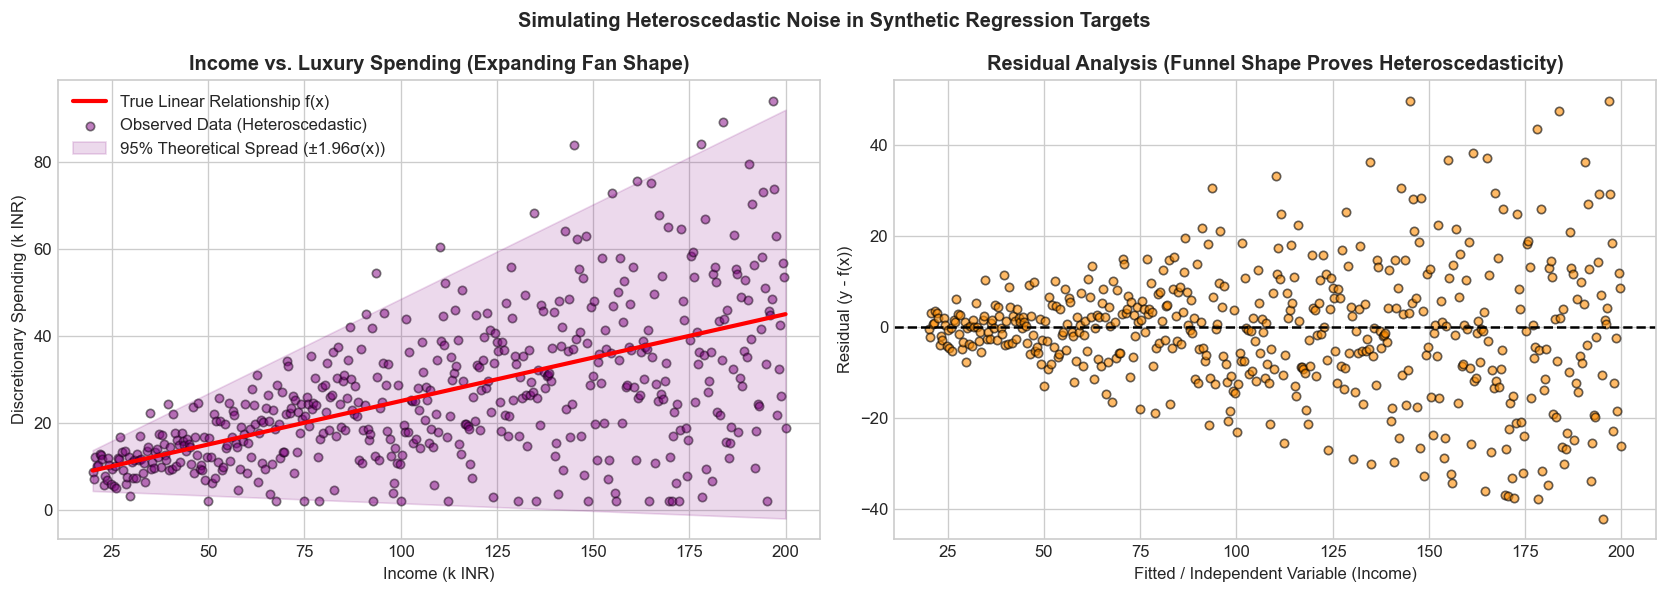

In [17]:
# ==============================================================================
# STEP 5: GENERATING HETEROSCEDASTIC (FAN-SHAPED) SYNTHETIC DATA
# ==============================================================================
N_points = 500
# Household Annual Income in thousands INR [20k to 200k]
income = np.linspace(20.0, 200.0, num=N_points)

# Ground truth spending trend: Base 5k + 20% of income
spending_true = 5.0 + 0.20 * income

# Heteroscedastic Noise: Standard deviation scales linearly with income! (sigma(x) = 0.12 * income)
noise_std = 0.12 * income
noise_hetero = rng.normal(loc=0.0, scale=noise_std)
spending_observed = np.maximum(2.0, spending_true + noise_hetero)  # Spending cannot be negative

# Plotting the classic 'Fan-Shaped' Heteroscedasticity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Scatter plot showing expanding variance
axes[0].plot(income, spending_true, color='red', linewidth=2.5, label='True Linear Relationship f(x)')
axes[0].scatter(income, spending_observed, color='purple', alpha=0.5, s=25, edgecolors='black', label='Observed Data (Heteroscedastic)')
axes[0].fill_between(income, spending_true - 1.96 * noise_std, spending_true + 1.96 * noise_std, color='purple', alpha=0.15, label='95% Theoretical Spread (±1.96σ(x))')
axes[0].set_title('Income vs. Luxury Spending (Expanding Fan Shape)', fontweight='bold')
axes[0].set_xlabel('Income (k INR)')
axes[0].set_ylabel('Discretionary Spending (k INR)')
axes[0].legend(loc='upper left')

# Subplot 2: Residual Plot (e_i vs x_i) proving violation of OLS constant variance
residuals = spending_observed - spending_true
axes[1].scatter(income, residuals, color='darkorange', alpha=0.6, s=25, edgecolors='black')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Analysis (Funnel Shape Proves Heteroscedasticity)', fontweight='bold')
axes[1].set_xlabel('Fitted / Independent Variable (Income)')
axes[1].set_ylabel('Residual (y - f(x))')

plt.suptitle('Simulating Heteroscedastic Noise in Synthetic Regression Targets', fontweight='bold')
plt.tight_layout()
plt.show()


## 5. Signal Recovery & Denoising Techniques

The primary goal of data analytics and signal processing is to **filter out the stochastic noise $\epsilon(t)$ and recover the true underlying signal $f(t)$**.

### Popular Digital Filtering Techniques:
1. **Simple Moving Average (SMA):** Smooths high-frequency jitter by averaging adjacent points in a rolling window $W$. (Can flatten peaks and introduce phase lag).
2. **Savitzky-Golay Filter (`scipy.signal.savgol_filter`):** Fits successive sub-sets of adjacent data points with a low-degree polynomial via linear least squares. **Crucial benefit:** Preserves peak heights and inflection points while smoothing out Gaussian noise.

### Evaluation Metric: Root Mean Squared Error (RMSE)
$$\text{RMSE} = \sqrt{\frac{1}{N} \sum_{i=1}^N \left(\hat{y}(t_i) - f(t_i)\right)^2}$$
A successful filter achieves a substantially lower RMSE against the true signal $f(t)$ than the raw noisy observation.

           SIGNAL RECOVERY PERFORMANCE EVALUATION (RMSE METRIC)          
Raw Noisy Observation RMSE    : 0.3836
Simple Moving Average (SMA)   : 0.1148 (Error reduced by 70.1%)
Savitzky-Golay Filter (Savgol): 0.1320 (Error reduced by 65.6%)


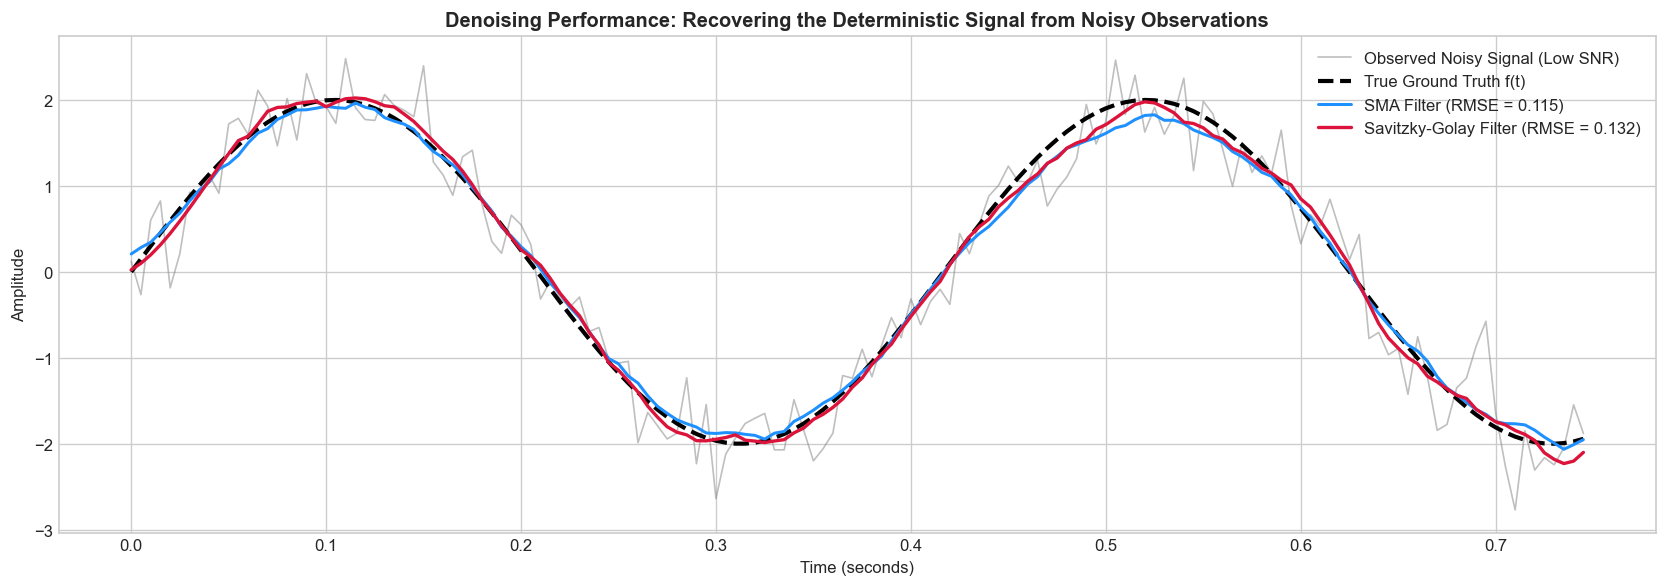

In [18]:
# ==============================================================================
# STEP 6: SIGNAL RECOVERY VIA MOVING AVERAGE & SAVITZKY-GOLAY FILTERING
# ==============================================================================

# Target noisy periodic signal from Step 2
target_clean = clean_signal
target_noisy = noisy_signal_low

# 1. Method A: Simple Moving Average (window = 15 points)
window_size = 15
kernel = np.ones(window_size) / window_size
sma_denoised = np.convolve(target_noisy, kernel, mode='same')

# 2. Method B: Savitzky-Golay Filter (window_length = 21, polynomial_order = 3)
# Preserves sinusoidal wave peaks better than simple moving average!
savgol_denoised = signal.savgol_filter(target_noisy, window_length=21, polyorder=3)

# 3. Compute Reconstruction Errors (RMSE against Ground Truth f(t))
rmse_raw = np.sqrt(np.mean((target_noisy - target_clean)**2))
rmse_sma = np.sqrt(np.mean((sma_denoised - target_clean)**2))
rmse_savgol = np.sqrt(np.mean((savgol_denoised - target_clean)**2))

print("=" * 75)
print("           SIGNAL RECOVERY PERFORMANCE EVALUATION (RMSE METRIC)          ")
print("=" * 75)
print(f"Raw Noisy Observation RMSE    : {rmse_raw:.4f}")
print(f"Simple Moving Average (SMA)   : {rmse_sma:.4f} (Error reduced by {(1 - rmse_sma/rmse_raw)*100:.1f}%)")
print(f"Savitzky-Golay Filter (Savgol): {rmse_savgol:.4f} (Error reduced by {(1 - rmse_savgol/rmse_raw)*100:.1f}%)")

# 4. Plot Signal Recovery Comparison
plt.figure(figsize=(14, 5))
plt.plot(t[:150], target_noisy[:150], color='gray', alpha=0.5, label='Observed Noisy Signal (Low SNR)', linewidth=1)
plt.plot(t[:150], target_clean[:150], color='black', linestyle='--', linewidth=2.5, label='True Ground Truth f(t)')
plt.plot(t[:150], sma_denoised[:150], color='dodgerblue', linewidth=1.8, label=f'SMA Filter (RMSE = {rmse_sma:.3f})')
plt.plot(t[:150], savgol_denoised[:150], color='crimson', linewidth=2.0, label=f'Savitzky-Golay Filter (RMSE = {rmse_savgol:.3f})')

plt.title('Denoising Performance: Recovering the Deterministic Signal from Noisy Observations', fontweight='bold')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 6. Summary & Signal Population Cheat Sheet

| Paradigm / Signal Type | Mathematical Definition | Python Code Template | Primary Use Case |
| :--- | :--- | :--- | :--- |
| **Periodic Sine Wave** | $f(t) = A\sin(2\pi ft) + \epsilon$ | `y = A * np.sin(2*np.pi*f*t) + rng.normal(0, s, N)` | Audio, sensor vibrations, biological signals. |
| **Polynomial Curve** | $f(x) = \sum c_i x^i + \epsilon$ | `y = np.polyval(coeffs, x) + rng.normal(0, s, N)` | Regression benchmarks, bias-variance analysis. |
| **Exponential Decay** | $f(x) = A e^{-\lambda x} + \epsilon$ | `y = A * np.exp(-lam * x) + rng.normal(0, s, N)` | Radioactive decay, customer churn, retention. |
| **Random Walk** | $P_t = P_0 + \sum \epsilon_i$ | `p = P0 + np.cumsum(rng.normal(0, s, N))` | Stock prices, currency rates, Brownian motion. |
| **Heteroscedastic Data** | $\epsilon_i \sim \mathcal{N}(0, (\alpha x_i)^2)$ | `noise = rng.normal(0, alpha * x, N)` | Income vs. luxury spending, financial volatility. |
| **Signal Recovery (Savgol)** | Local least-squares polynomial | `scipy.signal.savgol_filter(y, window, poly)` | Denoising while preserving peak shapes and inflection points. |